### Business Understanding and Planning Phase
Current Manual Process and Limitations- Loan aprroavals are currently reviewed manually buy loan officers.
The limitations of these include:- Inconsistent decisions due to subjective  judgement, slow response times which can lead to poor customer experience, Potential bias where some credit worthy applicants may be overlooked and scalability issues where manual review doesnt scale with growth.

Some of the key stakeholders and their needs include-
Loan officers - they need standardized, data-driven support to reduce bias and speed up decisions.
Applicants - they want a fast, fair and transparent loan approvals.
Risk Analytics Team - need robust, interpretable models to balance profit vs risk.
Regulators - require transparency anf explainability in credit decisions.
Executives - want improved profitability and reduced default losses.

Some o fthe implications of model Errors are: False approval(approve a bad loan) - very costly (~$50 000 loss)
False denial(reject a good loan) - moderate cost(~$8000 lost profit)
Precision on approvals is more critical than recall but both matter.

So, our choice of approach is regression where we predict the risk score over classification since this produces a continous probability of default.
Loan officers can also set thr threshholds dynamilcally based on the risk appetite of the business.
It is also more flexible for business use and reulatory reporting.
It also supports human-in-the-loop decision making.

### Modeling Goals and Sucess Criteria
The goal of the model will be to predict the applicant ris score(likelihood of default).
The sucess creteria will include: Minimizing the expected financial loss which will be done using a custom cost metric.
Achiving a strong discrimination ability(ROC-AUC >= 0.75)
Ensuring well calibrated probabilities(Brier score <= 0.20)
Providing interpretable outputs(SHAP values, feature importance)

### Evaluation Metrics
ROC-AUC - measures ability to separate good vs bad loans
Brier Score - measures calibration of predicted probabilities
Custom Expected Cost Metric: Expected Loss= (FP.50000) + (FN.8000)
It ties directly into the model evaluation business impact.

### Baseline Performance targets
ROC-AUC >= 0.75 which is better than random guessing at 0.5.
Brier Score <= 0.20 which implies that the model is well calibrated.
Expected Loss should be lower that current manual process(benchmark to be established from historical officers decisions).

In [108]:
# importing the necessary libraries
import pandas as pd
import numpy as np

In [109]:
df = pd.read_csv("financial_loan_data.csv")
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


First, we will be carrying out EDA and data cleacing to ensure we handle missing values.

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [111]:
print(df.shape)
print(df.dtypes)
df.isnull().sum().sort_values(ascending=False)

(20000, 35)
Age                             int64
AnnualIncome                   object
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory              object
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyIncome                 float64


MaritalStatus                 1331
EducationLevel                 901
SavingsAccountBalance          572
CreditScore                      0
AnnualIncome                     0
Age                              0
Experience                       0
LoanAmount                       0
LoanDuration                     0
NumberOfDependents               0
EmploymentStatus                 0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
HomeOwnershipStatus              0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

In [112]:
df["EducationLevel"] = df["EducationLevel"].fillna("Unknown")

In [113]:
df["SavingsAccountBalance"] = df["SavingsAccountBalance"].fillna(0)

In [114]:
df["MaritalStatus"] = df["MaritalStatus"].fillna("Unknown")

In [115]:
df.isnull().sum()

Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
InterestRate                  0
MonthlyL

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

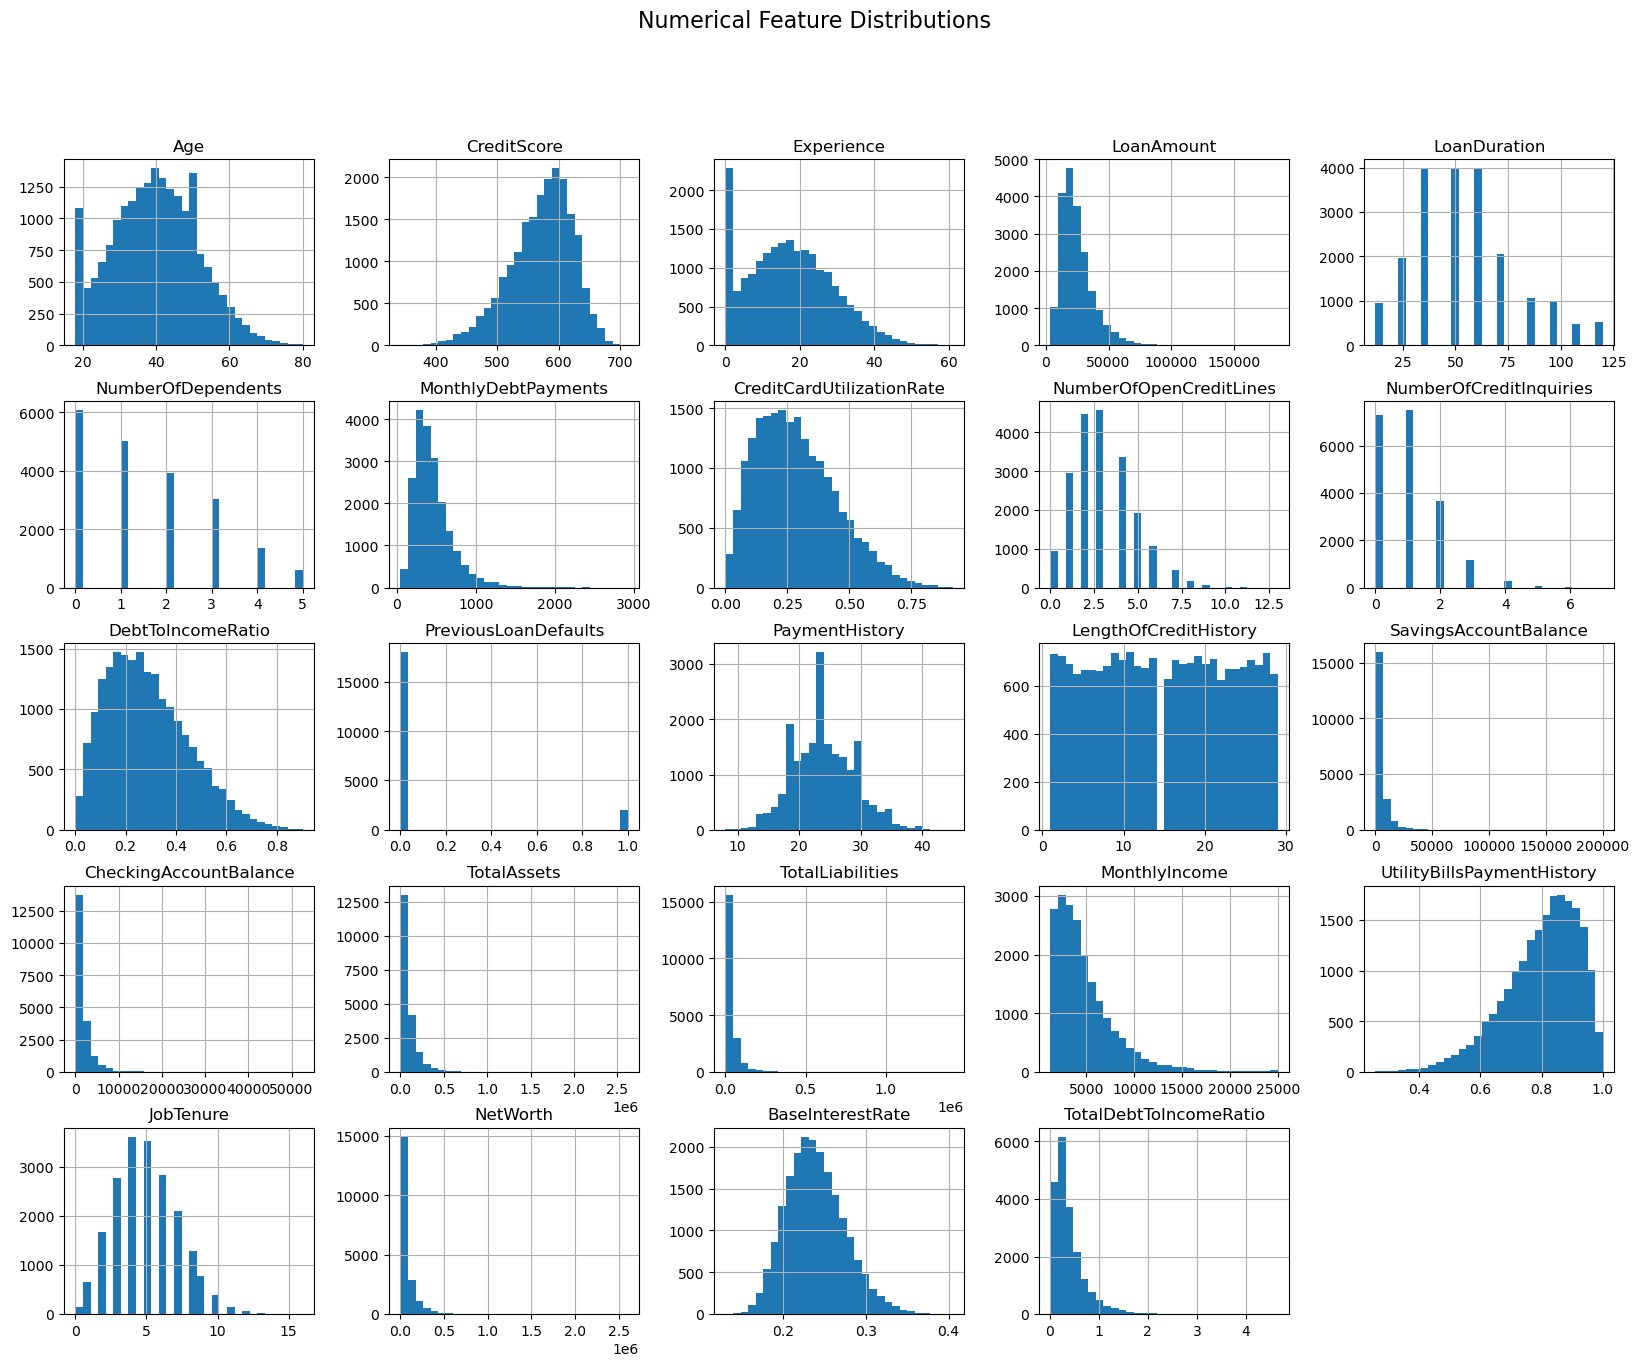

In [117]:

# Select numerical columns
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()

# Drop target/leakage if needed
num_cols = [col for col in num_cols if col not in ["RiskScore","LoanApproved","InterestRate","MonthlyLoanPayment"]]

# Plot histograms
df[num_cols].hist(bins=30, figsize=(20,15))
plt.suptitle("Numerical Feature Distributions", fontsize=16)
plt.show()


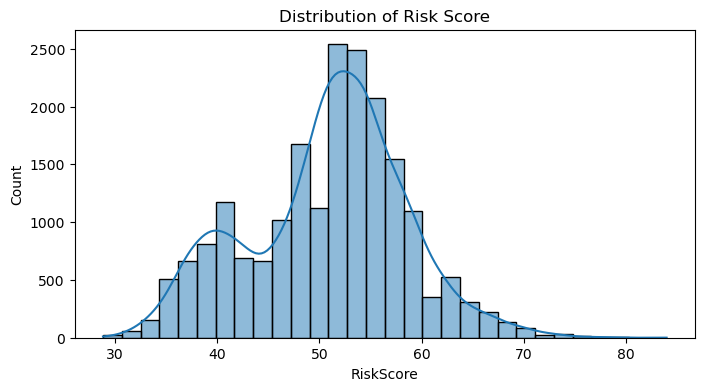

In [118]:
plt.figure(figsize=(8,4))
sns.histplot(df["RiskScore"], bins=30, kde=True)
plt.title("Distribution of Risk Score")
plt.show()


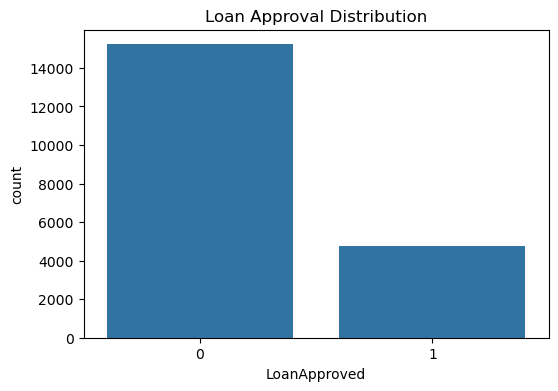

In [119]:
plt.figure(figsize=(6,4))
sns.countplot(x="LoanApproved", data=df)
plt.title("Loan Approval Distribution")
plt.show()


### Data Understanding and exploration
Basic data characteristics include:
20000 loan applications
35 feature: mix of numerical(18) and categorical(7)
Targets are riskscore(continous), loanapproaved(binary)
missing values:
Marital Status(6.7%)
Education Level(4.5%)
SavingsAccountBalance(2.9%)
NO missingness in other features

### Data Quality Issues
Misssing values
Potential leakages which might need to be excluded from training
Outliers such us extreme incomes which may distort scaling.

### Feature Understanding
Normalizing skewed financial varables
Encode categorical features
Handling missing values explicitly 

In [120]:
# Clean AnnualIncome column
df["AnnualIncome"] = (df["AnnualIncome"].replace('[\$,]', '', regex=True).astype(float))


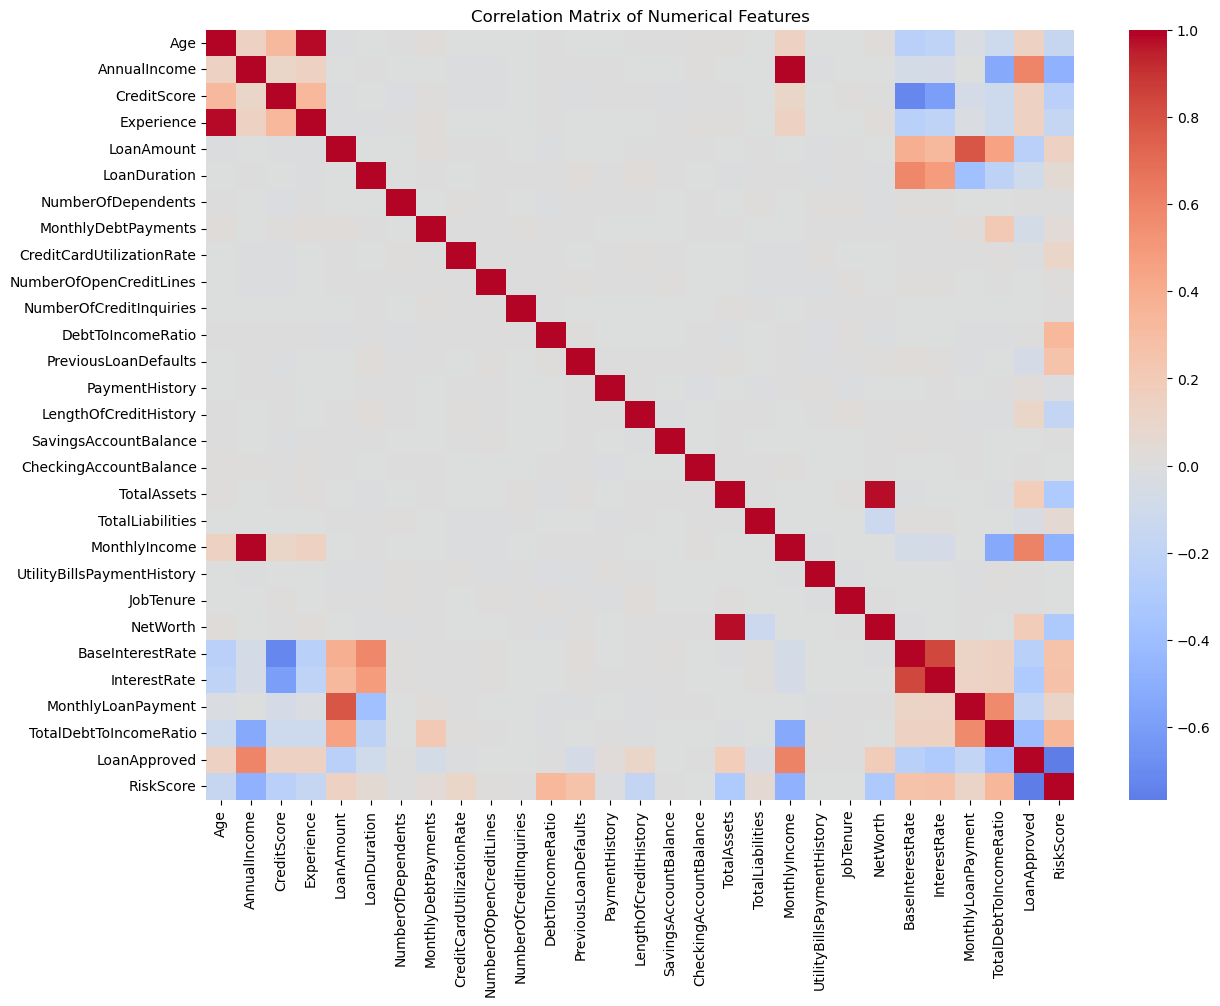

In [121]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Features")
plt.show()


In [122]:
print(df.columns.tolist())


['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']


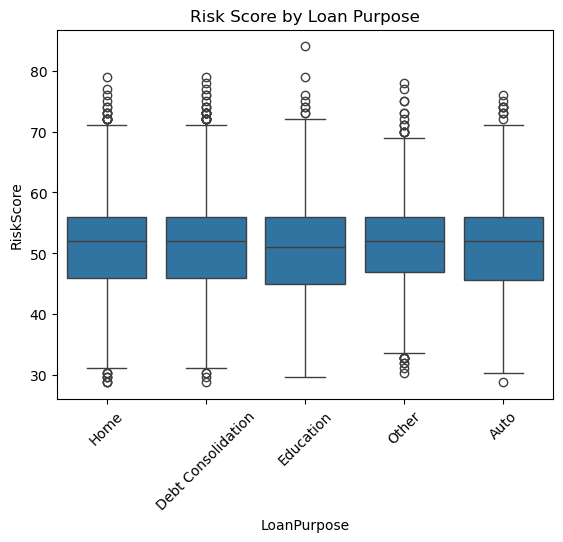

In [123]:
sns.boxplot(x="LoanPurpose", y="RiskScore", data=df)
plt.xticks(rotation=45)
plt.title("Risk Score by Loan Purpose")
plt.show()


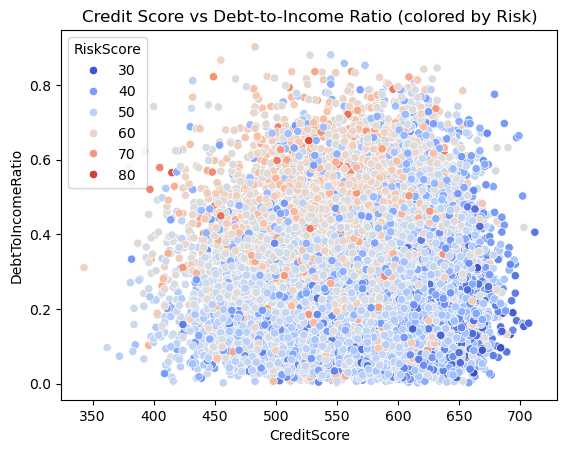

In [124]:
sns.scatterplot(x="CreditScore", y="DebtToIncomeRatio", hue="RiskScore", data=df, palette="coolwarm")
plt.title("Credit Score vs Debt-to-Income Ratio (colored by Risk)")
plt.show()


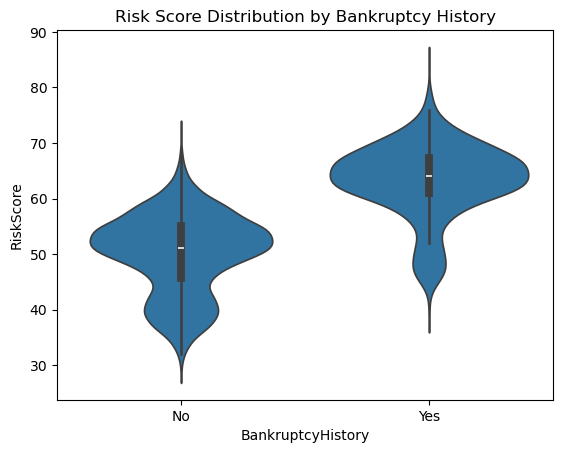

In [125]:
sns.violinplot(x="BankruptcyHistory", y="RiskScore", data=df)
plt.title("Risk Score Distribution by Bankruptcy History")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, roc_auc_score, r2_score, mean_absolute_error

In [142]:
# defining the Features and target
# drop the leakage columns
drop_cols = ["LoanApproved", "RiskScore","InterestRate","MonthlyLoanPayment"]
X = df.drop(columns=drop_cols)
y = df["RiskScore"]

# Preprocessing
num_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

preprocessor = ColumnTransformer([("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_features), ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), cat_features)])


# Train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
gb_reg = Pipeline([("preprocessor", preprocessor), ("model", GradientBoostingRegressor(n_estimators=300, max_depth=7, random_state=42))])

gb_reg.fit(X_train, y_train)
y_pred = gb_reg.predict(X_test)

# Evaluation

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 7.038048181038772


In [154]:

# Get the trained regressor from the pipeline
model = gb_reg.named_steps["model"]

# Get feature names after preprocessing
# Numeric features stay the same, categorical are expanded by OneHotEncoder
ohe = gb_reg.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]
cat_feature_names = ohe.get_feature_names_out(cat_features)

feature_names = np.concatenate([num_features, cat_feature_names])

# Extract feature importances
importances = model.feature_importances_

# Put into a DataFrame for readability
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp.head(20))  # top 20 features

                      Feature  Importance
24     TotalDebtToIncomeRatio    0.156335
11          DebtToIncomeRatio    0.122482
22                   NetWorth    0.117238
19              MonthlyIncome    0.093711
43       BankruptcyHistory_No    0.089343
1                AnnualIncome    0.071415
12       PreviousLoanDefaults    0.068457
44      BankruptcyHistory_Yes    0.057575
14      LengthOfCreditHistory    0.047221
23           BaseInterestRate    0.044262
2                 CreditScore    0.043697
25  EmploymentStatus_Employed    0.018341
8   CreditCardUtilizationRate    0.013721
17                TotalAssets    0.010537
4                  LoanAmount    0.006531
5                LoanDuration    0.004080
7         MonthlyDebtPayments    0.003455
16     CheckingAccountBalance    0.003219
15      SavingsAccountBalance    0.002889
18           TotalLiabilities    0.002876


In [146]:
# Converting risk score to binary
threshold = np.median(y_test)
y_pred_class = (y_pred >= threshold).astype(int)
y_true_class = (y_test >= threshold). astype(int)


In [147]:
#ROC-AUC
auc= roc_auc_score(y_true_class, y_pred)
print("ROC-AUC:", auc)


ROC-AUC: 0.9640544630725932


In [144]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R²:", r2)

MAE: 1.658076082736085
R²: 0.886642999900817


In [149]:
# Create a DataFrame with actual vs predicted
results = pd.DataFrame({"Actual RiskScore": y_test, "Predicted RiskScore": y_pred})
print(results.head(20))  # show first 20 rows


       Actual RiskScore  Predicted RiskScore
10650              41.6            42.989651
2041               38.4            37.612735
8668               53.0            51.690906
1114               50.0            49.339408
13902              51.0            51.429790
11963              47.0            43.680686
11072              52.0            51.119484
3002               46.0            46.274783
19771              69.0            68.056162
8115               55.0            54.128490
3525               58.0            57.819077
7879               60.0            58.553663
16441              34.4            37.854673
16296              37.6            38.683292
12566              38.4            39.462006
5252               50.0            46.445886
19393              50.0            50.222524
16796              56.0            56.366033
8094               52.0            49.566704
322                58.0            58.927997


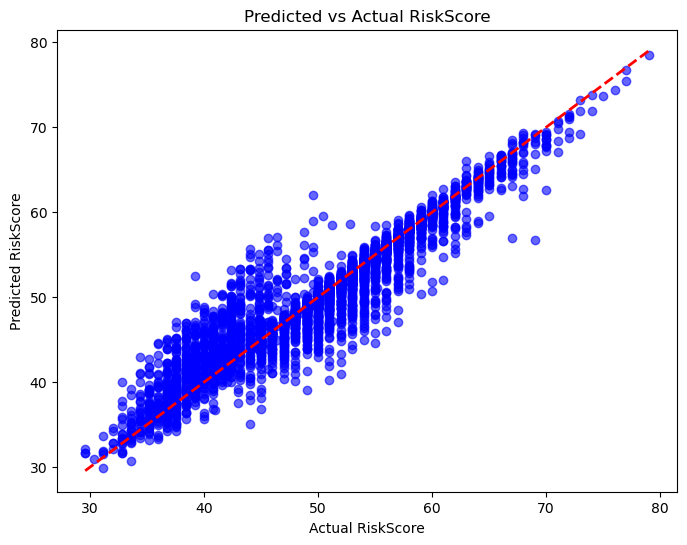

In [150]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)  # perfect prediction line

plt.xlabel("Actual RiskScore")
plt.ylabel("Predicted RiskScore")
plt.title("Predicted vs Actual RiskScore")
plt.show()


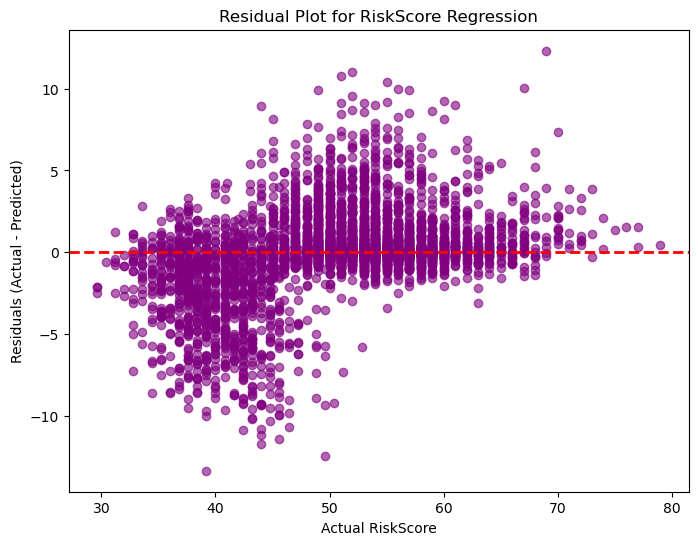

In [151]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_test, residuals, alpha=0.6, color="purple")
plt.axhline(0, color="red", linestyle="--", lw=2)

plt.xlabel("Actual RiskScore")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for RiskScore Regression")
plt.show()

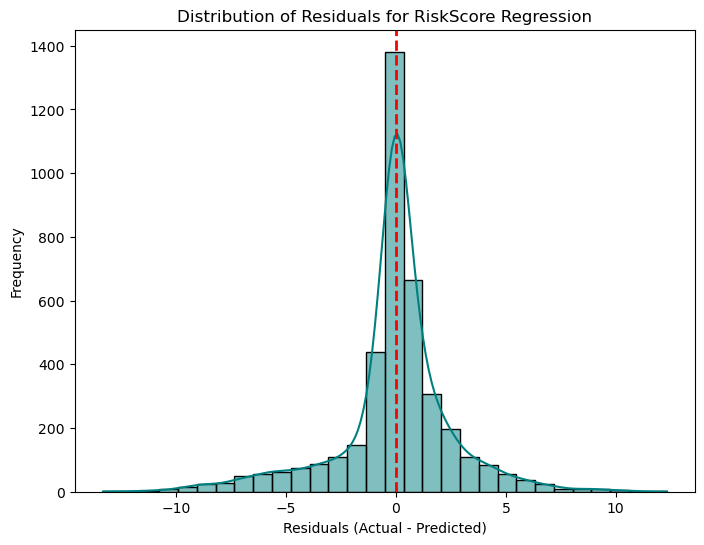

In [153]:
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True, color="teal", bins=30)
plt.axvline(0, color="red", linestyle="--", lw=2)

plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals for RiskScore Regression")
plt.show()

The residual distribution looks excellent. It's sharply centered around zero, meaning our model's predictions are unbiased overall. The tall , narrow peak shows most most residual are small, while the slightly heavy tails suggest a few larger deviations for extreme risk cases.. This pattern is typical for well-performing financial regressions where the center is at 0 where there is no systematic over- or under prediction. There is symmetry where balanced errors across low and high risk scores. There are heavy tails where occasional outliers are represented, which are often high-risk applicants with complex profiles.